In [1]:
import yfinance as yf
import pandas as pd
import pathlib
import numpy as np

In [2]:
# Define the symbols
symbols = ['KO', 'WMT', 'VOO']

# If we don's have the data then grab it
if not pathlib.Path(r'C:\Users\carle\Documents\Portafolio Optimization\Yahoo\data\stock_data.csv').exists():

    # Inizialize the client
    price_data_frame = yf.download(symbols, start='2020-01-01', end='2024-01-01')

    # Save the csv
    price_data_frame.to_csv(r'C:\Users\carle\Documents\Portafolio Optimization\Yahoo\data\stock_data.csv')
    print(price_data_frame)

else:

    # Load the data
    price_data_frame = pd.read_csv(r'C:\Users\carle\Documents\Portafolio Optimization\Yahoo\data\stock_data.csv')
    print(price_data_frame)


# The data is close to what we need but we need a single column for each symbol, where each column contains the close price
price_data_frame = pd.read_csv(
    r'C:\Users\carle\Documents\Portafolio Optimization\Yahoo\data\stock_data.csv',
    header=[0, 1],
    index_col=0
)

price_data_frame = price_data_frame['Close']


/tmp/ipykernel_55823/2639809101.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data_frame = yf.download(symbols, start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  3 of 3 completed

Price           Close                              High              \
Ticker             KO         VOO        WMT         KO         VOO   
Date                                                                  
2020-01-02  45.432709  272.760345  36.359207  45.796235  272.787765   
2020-01-03  45.184849  270.767792  36.038231  45.432711  271.791484   
2020-01-06  45.168324  271.782318  35.964870  45.366613  271.846306   
2020-01-07  44.821320  271.032776  35.631672  45.110488  271.709138   
2020-01-08  44.903950  272.431305  35.509392  45.143548  273.573824   
...               ...         ...        ...        ...         ...   
2023-12-22  54.594421  424.419769  51.004307  54.725477  425.931050   
2023-12-26  54.819088  426.184570  50.926167  54.959504  426.984100   
2023-12-27  54.959503  426.964539  51.404785  55.015672  427.081537   
2023-12-28  54.996952  427.032745  51.303860  55.109285  427.881014   
2023-12-29  55.165455  425.891998  51.329906  55.212260  427.393549   

Price

# Portfolio Return, Risk, and the Sharpe Ratio

Consider a portfolio with $n$ assets. Its return is given by

$$R_p = \sum_{i=1}^{n} w_i r_i$$

where $r_i$ is the return of asset $i$ and $w_i$ is the portfolio weight assigned to asset $i$, with

$$\sum_{i=1}^{n} w_i = 1$$

This means that the portfolio return is a weighted average of the individual asset returns. Assets with larger weights have a larger effect on the total portfolio performance.

---

## Variance and Covariance

To measure risk, we use the variance and the standard deviation of portfolio returns. The basic definitions are

$$\operatorname{Var}(X) = E(X^2) - E(X)^2$$

and

$$\operatorname{Cov}(X,Y) = E(XY) - E(X)E(Y)$$

Variance measures the dispersion of a variable around its mean, while covariance measures how two variables move together. In portfolio analysis, this second concept is important because the total risk of a portfolio depends not only on the risk of each asset individually, but also on the relationship between their returns.

---

## Two-Asset Portfolio

For a two-asset portfolio,

$$R_p = w_1 r_1 + w_2 r_2$$

the portfolio variance is

$$\operatorname{Var}(R_p) = w_1^2 \operatorname{Var}(r_1) + w_2^2 \operatorname{Var}(r_2) + 2 w_1 w_2 \operatorname{Cov}(r_1,r_2)$$

The first two terms capture the contribution of each asset's own risk. The covariance term captures whether the two assets tend to move together or offset each other.

- If the covariance is **positive**, the assets tend to move in the same direction → **increases portfolio risk**
- If the covariance is **negative**, they tend to offset one another → **reduces portfolio risk** (diversification benefits)

Using correlation, we can also write

$$\operatorname{Cov}(r_1,r_2) = \rho_{12}\sigma_1\sigma_2$$

so the portfolio variance becomes

$$\sigma_p^2 = w_1^2 \sigma_1^2 + w_2^2 \sigma_2^2 + 2 w_1 w_2 \rho_{12}\sigma_1\sigma_2$$

Therefore, the standard deviation of the portfolio is

$$\sigma_p = \sqrt{\sigma_p^2}$$

---

## The Sharpe Ratio

The Sharpe Ratio is defined as

$$\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}$$

where $R_p$ is the portfolio return, $R_f$ is the risk-free rate, and $\sigma_p$ is the standard deviation of portfolio returns.

- The **numerator** $R_p - R_f$ is the excess return over the risk-free asset
- The **denominator** measures the total risk taken to obtain that excess return

$$\text{Sharpe Ratio} = \frac{\text{Excess Return}}{\text{Risk}}$$

A **higher Sharpe Ratio** means more excess return per unit of risk.

In [3]:
# Calculate the log of returns + 1
log_return = np.log(1 + price_data_frame.pct_change())    # Ex: 1.05 times

# Generate random weights given the number of symbols
number_of_symbols = len(symbols)
random_weights = np.array(np.random.random(number_of_symbols))  # [0,1]

# Generate the Rebalance Weights, these should equal 1 as explained in the previous theory
rebalanced_weights = random_weights/np.sum(random_weights)

# Calculate expected return
exp_return = np.sum((log_return.mean() * rebalanced_weights) * 252)  # Anualizing given working days

# Calculate the Expected Volatility, annualize it by multiplying it by `252`.
# Use the formula for varianze
exp_vol = np.sqrt(
np.dot(
    rebalanced_weights.T,
    np.dot(
        log_return.cov() * 252,
        rebalanced_weights
    )
)
)

# Risk-free
risk_free = 0

# Compute the sharp ratio
sharpe_ratio = (exp_return - risk_free) / exp_vol

# Put all the metrics into data frames to visualize
weights_df = pd.DataFrame(data={
    'random weights':random_weights,
    'rebalanced weights':rebalanced_weights
})
print('')
print('='*50)
print('PORTFOLIO WEIGHTS:')
print('-'*50)
print(weights_df)
print('-'*50)

metrics_df = pd.DataFrame(data={
    'Expected portafolio returns': exp_return,
    'Expected volatibility (var)': exp_vol,
    'Sharp ratio': sharpe_ratio
}, index=[0])

print('')
print('='*80)
print('PORTFOLIO METRICS:')
print('-'*80)
print(metrics_df)
print('-'*80)



PORTFOLIO WEIGHTS:
--------------------------------------------------
   random weights  rebalanced weights
0        0.314728            0.342868
1        0.006965            0.007587
2        0.596235            0.649545
--------------------------------------------------

PORTFOLIO METRICS:
--------------------------------------------------------------------------------
   Expected portafolio returns  Expected volatibility (var)  Sharp ratio
0                     0.073698                     0.199317     0.369751
--------------------------------------------------------------------------------


In [4]:
# Monte carlos

#Define number of simulations (portafolios)
num_of_portafolios = 5000

# Array for wigths of each simulatios
all_weights = np.zeros((num_of_portafolios, number_of_symbols))

# Array for retunr of each simulatios
ret_arr = np.zeros(num_of_portafolios)

# Array number of volatibilities (sd of each portafolio)
vol_arr = np.zeros(num_of_portafolios)

# Array sharp ratios
sharpe_arr = np.zeros(num_of_portafolios)

# Simulation
for ind in range(num_of_portafolios):
    #Calculate weights sum=1
    weights = np.array(np.random.random(number_of_symbols))
    weights = weights/np.sum(weights)

    # Save in weights array
    all_weights[ind, :] = weights

    # Calculate the expected log returns
    ret_arr[ind] = np.sum((log_return.mean()*weights)*252)

    # Calculate the volatility, and add them to the `volatility_array`.
    vol_arr[ind] = np.sqrt(
        np.dot(weights.T, np.dot(log_return.cov() * 252, weights))
    )

    # Calculate the Sharpe Ratio and Add it to the `sharpe_ratio_array`.
    sharpe_arr[ind] = ret_arr[ind]/vol_arr[ind]

# Let's create our "Master Data Frame", with the weights, the returns, the volatility, and the Sharpe Ratio
simulations_data = [ret_arr, vol_arr, sharpe_arr, all_weights]

# Create a DataFrame from it, then Transpose it so it looks like our original one.
simulations_df = pd.DataFrame(data=simulations_data).T

# Give the columns the Proper Names.
simulations_df.columns = [
    'Returns',
    'Volatility',
    'Sharpe Ratio',
    'Portfolio Weights'
]

# Make sure the data types are correct, we don't want our floats to be strings.
simulations_df = simulations_df.infer_objects()

# Print out the results.
print('')
print('='*80)
print('SIMULATIONS RESULT:')
print('-'*80)
print(simulations_df.head())
print('-'*80)


SIMULATIONS RESULT:
--------------------------------------------------------------------------------
    Returns  Volatility  Sharpe Ratio  \
0  0.077049    0.189573      0.406433   
1  0.078099    0.193562      0.403486   
2  0.090400    0.203229      0.444819   
3  0.080441    0.190674      0.421878   
4  0.073154    0.191513      0.381981   

                                   Portfolio Weights  
0  [0.40715999769856126, 0.23638966392225935, 0.3...  
1  [0.30899846619509697, 0.13113943488728885, 0.5...  
2  [0.2964645977809405, 0.5992336727842931, 0.104...  
3  [0.3046918426145126, 0.217377922132219, 0.4779...  
4  [0.41583204774565974, 0.09522826830007443, 0.4...  
--------------------------------------------------------------------------------




**Max Sharpe Ratio and Min Volatility**

After running 5000 simulations, we look for two key portfolios.

The first one is the **max Sharpe Ratio** portfolio. This is the "best" portfolio because it generates the highest return for each unit of risk we take on.

The second one is the **min volatility** portfolio. This is the most conservative option. It takes the least amount of risk, but it does not necessarily give the best return.

In [7]:
max_sharpe_ratio = simulations_df.loc[simulations_df['Sharpe Ratio'].idxmax()]
min_volatility = simulations_df.loc[simulations_df['Volatility'].idxmin()]

print('')
print('='*100)
print('MAX SHARPE RATIO:')
print('-'*100)
print(max_sharpe_ratio)
print('-'*100)

print('')
print('='*100)
print('MIN VOLATILITY:')
print('-'*100)
print(min_volatility)
print('-'*100)


MAX SHARPE RATIO:
----------------------------------------------------------------------------------------------------
Returns                                                       0.103694
Volatility                                                    0.203678
Sharpe Ratio                                                  0.509108
Portfolio Weights    [0.0001947793950886636, 0.6822235607911766, 0....
Name: 2982, dtype: object
----------------------------------------------------------------------------------------------------

MIN VOLATILITY:
----------------------------------------------------------------------------------------------------
Returns                                                        0.07841
Volatility                                                    0.189424
Sharpe Ratio                                                   0.41394
Portfolio Weights    [0.37477548275820655, 0.24183414106802117, 0.3...
Name: 4325, dtype: object
-----------------------------------------

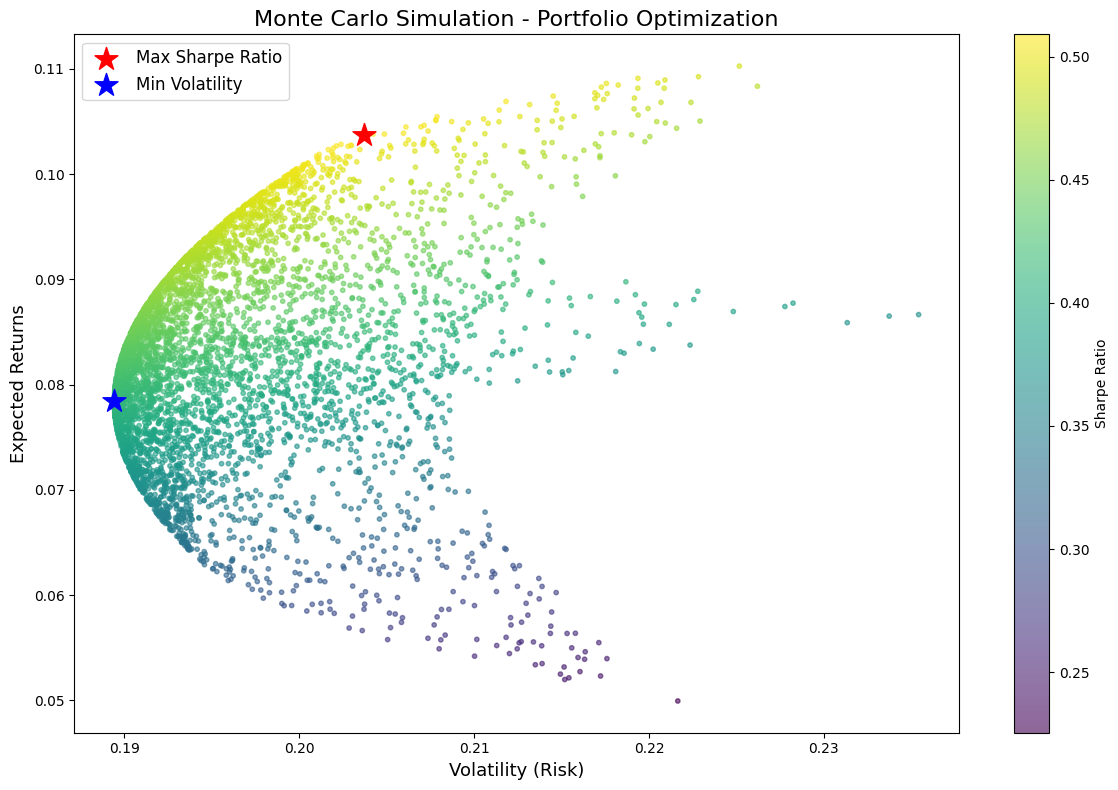

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))

# Graficar todas las simulaciones, coloreadas por Sharpe Ratio
scatter = ax.scatter(
    simulations_df['Volatility'],
    simulations_df['Returns'],
    c=simulations_df['Sharpe Ratio'],
    cmap='viridis',
    alpha=0.6,
    s=10
)

# Barra de color
plt.colorbar(scatter, label='Sharpe Ratio')

# Marcar el punto de Max Sharpe Ratio
ax.scatter(
    max_sharpe_ratio['Volatility'],
    max_sharpe_ratio['Returns'],
    color='red',
    marker='*',
    s=300,
    label='Max Sharpe Ratio'
)

# Marcar el punto de Min Volatility
ax.scatter(
    min_volatility['Volatility'],
    min_volatility['Returns'],
    color='blue',
    marker='*',
    s=300,
    label='Min Volatility'
)

# Etiquetas y titulo
ax.set_xlabel('Volatility (Risk)', fontsize=13)
ax.set_ylabel('Expected Returns', fontsize=13)
ax.set_title('Monte Carlo Simulation - Portfolio Optimization', fontsize=16)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()